**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of multiple fluorophores](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [PFA data](#toc1_1_1_)    
      - [2 fluorophores](#toc1_1_1_1_)    
      - [3 Fluorophores](#toc1_1_1_2_)    
      - [4 fluorophores](#toc1_1_1_3_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure](#toc1_2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of multiple fluorophores](#toc0_)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.distributions as dist
import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.fitting as fitting
import fluopy.routines as rt

%load_ext autoreload
%autoreload 2

reading_from_1 = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_4_multi_f_PFA"
)
reading_from_2 = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_5_modeling"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[PFA data](#toc0_)

#### <a id='toc1_1_1_1_'></a>[2 fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_2f_all = []
parameters_2f_all = []
for i, id in enumerate(identifiers):
    fingerprints_2f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(reading_from_1 + "/2F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_2f_all[i] += pd.read_parquet(file).sum(axis=1)
    fingerprint = fingerprints_2f_all[i].cumsum() / fingerprints_2f_all[i].sum()
    fingerprints_2f_all[i] = fingerprint
    parameter_file = reading_from_2 + f"/2F/{id}/parameters_2F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_2f_all.append(parameter_dict)

#### <a id='toc1_1_1_2_'></a>[3 Fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_3f_all = []
parameters_3f_all = []
for i, id in enumerate(identifiers):
    fingerprints_3f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    for file in Path(reading_from_1 + "/3F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            fingerprints_3f_all[i] += pd.read_parquet(file).sum(axis=1)
    fingerprint = fingerprints_3f_all[i].cumsum() / fingerprints_3f_all[i].sum()
    fingerprints_3f_all[i] = fingerprint
    parameter_file = reading_from_2 + f"/3F/{id}/parameters_3F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_3f_all.append(parameter_dict)

#### <a id='toc1_1_1_3_'></a>[4 fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_4f_all = []
fingerprints_4f_all_truncated = []
localizations_4f_all = []
OFF_periods_4f_all = []
ON_periods_4f_all = []
number_ON_periods_4f_all = []
intensities_4f_all = []
parameters_4f_all = []
emis = em.Emissions()
for i, id in enumerate(identifiers):
    fingerprints_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    localizations_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_4f_all.append([])
    ON_periods_4f_all.append([])
    intensities_4f_all.append([])
    number_ON_periods_4f_all.append([])
    for file in Path(reading_from_1 + "/4F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data = pd.read_parquet(file)
            non_zero = data[data > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_4f_all[i] += data.sum(axis=1)
            localizations_4f_all[i] += (data > 0).sum(axis=1)
            intensities_4f_all[i] += non_zero.tolist()
            for col in data.columns:
                emis.event_time_series = data[col]
                blinks = bl.Blinking(emis)
                OFF_periods_4f_all[i] += blinks.off_periods.tolist()
                ON_periods_4f_all[i] += blinks.on_periods.tolist()
                number_ON_periods_4f_all[i].append(blinks.on_periods.size)
    fingerprint = fingerprints_4f_all[i].cumsum() / fingerprints_4f_all[i].sum()
    fingerprints_4f_all[i] = fingerprint
    loc_fingerprint = localizations_4f_all[i].cumsum() / localizations_4f_all[i].sum()
    localizations_4f_all[i] = loc_fingerprint
    fingerprint_truncated = rt.truncate_fingerprints(
        fingerprint,
        low=3000,
    )
    fingerprints_4f_all_truncated.append(fingerprint_truncated)
    parameter_file = reading_from_2 + f"/4F/{id}/parameters_4F_{id}.npy"
    parameter_dict = fitting.load_from_array(parameter_file)
    parameters_4f_all.append(parameter_dict)

## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_1_'></a>[Preparation](#toc0_)

In [11]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


OFF_periods_4f_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_4f_all
]
log_bins_OFF_4f = get_log_bins(OFF_periods_4f_all)
weights_OFF_4f = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_4f_all
]
ON_periods_4f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_4f_all]
log_bins_ON_4f = get_log_bins(ON_periods_4f_all)
weights_ON_4f = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_all
]
intensities_4f_all = [np.array(intensities) for intensities in intensities_4f_all]
weights_intensities_4f = [
    np.ones_like(intensities) / len(intensities) for intensities in intensities_4f_all
]

number_ON_periods_4f_all = [
    np.array(number_ON_periods) for number_ON_periods in number_ON_periods_4f_all
]
weights_number_ON_periods = [
    np.ones_like(number_ON_periods) / number_ON_periods.size
    for number_ON_periods in number_ON_periods_4f_all
]

### <a id='toc1_2_2_'></a>[Figure](#toc0_)

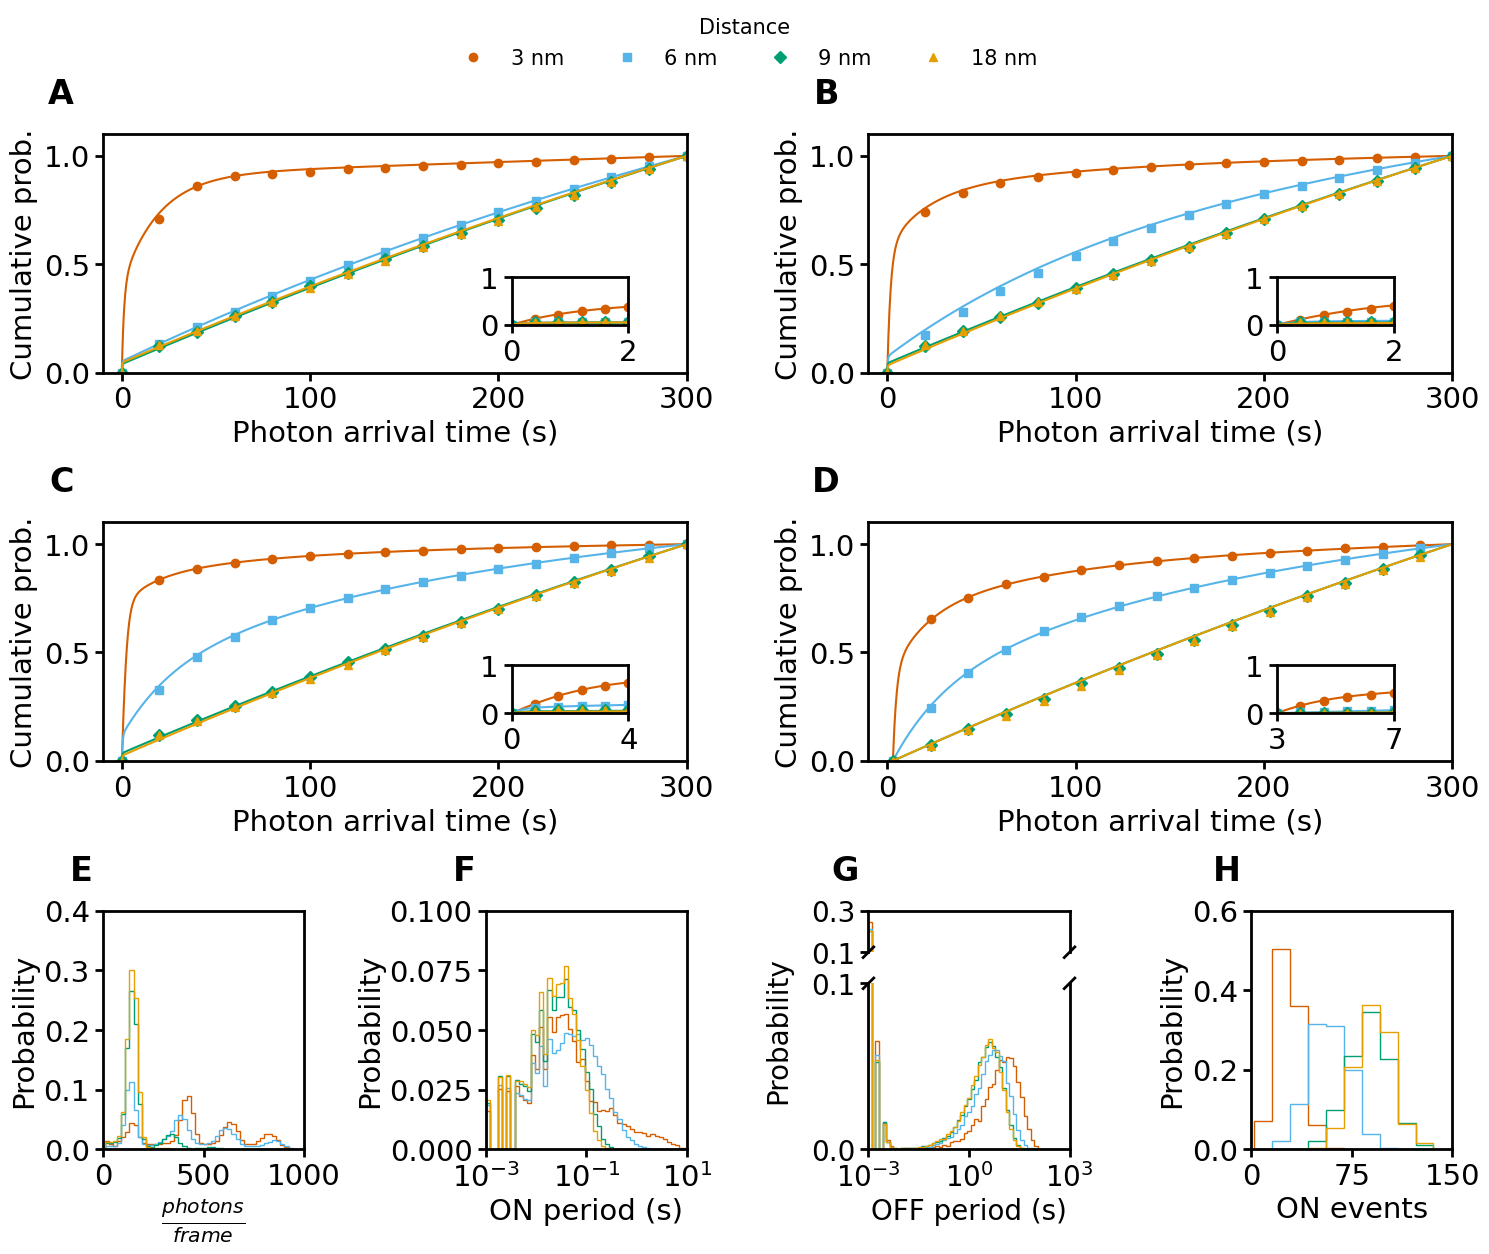

In [25]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]


def plot_figure3(
    ax,
    labels,
    data,
    fit,
    xlim2,
    ylim2,
    spacing2,
    inset_x_ticks,
    colors=colors,
    truncated=None,
):
    if truncated is not None:
        domain = truncated
    else:
        domain = (0, 300)
    markers = ["o", "s", "D", "^"]
    x = np.linspace(0, 300, 1000)
    spacing1 = 20000
    description = dict(
        ylabel="Cumulative prob.",
        xlabel="Photon arrival time (s)",
        xlim=[-10, 300],
        ylim=[0, 1.1],
    )
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        fi.universal_figure(
            data=[fingerprint.index[::spacing1], fingerprint[::spacing1]],
            label=label,
            color=color,
            marker=marker,
            linestyle="",
            axes=ax,
        )
        fi.universal_figure(
            data=[
                x,
                dist.Photoswitching_fingerprint_model(
                    params=parameters, domain=domain
                ).cdf(x),
            ],
            color=color,
            axes=ax,
        )
    fi.universal_figure(
        axes=ax,
        **description,
    )

    inset = ax.inset_axes([0.7, 0.2, 0.2, 0.2], xlim=xlim2, ylim=(0, ylim2))
    x = np.linspace(0, 300, 100000)
    for fingerprint, parameters, label, color, marker in zip(
        data, fit, labels, colors, markers
    ):
        fi.universal_figure(
            data=[fingerprint.index[::spacing2], fingerprint[::spacing2]],
            axes=inset,
            label=label,
            color=color,
            marker=marker,
            linestyle="",
        )
        fi.universal_figure(
            data=[
                x,
                dist.Photoswitching_fingerprint_model(
                    params=parameters, domain=domain
                ).cdf(x),
            ],
            color=color,
            axes=inset,
        )
    inset.set_ylabel("")
    inset.set_xlabel("")
    inset.set_xticks(inset_x_ticks)


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))


labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"
ax1 = fig.add_subplot(gs[0, 0:2])
plot_figure3(
    ax1,
    labels1,
    fingerprints_2f_all,
    parameters_2f_all,
    (0, 2),
    1,
    400,
    [0, 2],
)

ax2 = fig.add_subplot(gs[0, 2:])
plot_figure3(
    ax2,
    labels1,
    fingerprints_3f_all,
    parameters_3f_all,
    (0, 2),
    1,
    400,
    [0, 2],
)

ax3 = fig.add_subplot(gs[1, 0:2])
plot_figure3(
    ax3,
    labels1,
    fingerprints_4f_all,
    parameters_4f_all,
    (0, 4),
    1,
    800,
    [0, 4],
)

ax4 = fig.add_subplot(gs[1, 2:])
plot_figure3(
    ax4,
    labels1,
    fingerprints_4f_all_truncated,
    parameters_4f_all,
    (3, 7),
    1,
    800,
    [3, 7],
    truncated=(3, 300),
)

ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    type_="hist",
    data=list(reversed(intensities_4f_all)),
    axes=ax5,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=50,
    weights=list(reversed(weights_intensities_4f)),
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.4],
    xlim=[0, 1000],
)
ax6 = fig.add_subplot(gs[2, 1])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_4f_all)),
    axes=ax6,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=log_bins_ON_4f,
    weights=list(reversed(weights_ON_4f)),
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    xlim=[1e-3, 1e1],
)

bax7 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax7.hist(
    list(reversed(OFF_periods_4f_all)),
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_OFF_4f,
    weights=list(reversed(weights_OFF_4f)),
)
bax7.set_xscale("log")
bax7.set_ylabel("Probability", fontsize=20, labelpad=55)
bax7.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax7.tick_params(labelsize=20, width=2, length=6)
bax7.set_xlim([1e-3, 1e3])
bax7.set_xticks([1e-3, 1e0, 1e3])
bax7.axs[0].set_yticks([0.1, 0.3])
bax7.axs[1].set_yticks([0, 0.1])

ax8 = fig.add_subplot(gs[2, 3])
fi.universal_figure(
    type_="hist",
    data=list(reversed(number_ON_periods_4f_all)),
    axes=ax8,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 150],
    ylim=[0, 0.6],
    xticks=[0, 75, 150],
    weights=list(reversed(weights_number_ON_periods)),
)

letters = ["A", "B", "C", "D", "E", "F", "G", "H"]
axes = fig.get_axes()
j = 0
for i, axis in enumerate(axes):
    if i in [6, 7]:
        continue
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    title="Distance",
    title_fontsize=15,
    fontsize=15,
)
fig.tight_layout()
for handle in bax7.diag_handles:
    handle.remove()
bax7.draw_diags()

fig.savefig(
    reading_from_1 + r"\multi_f_PFA.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)